# 🎬 Hybrid Movie Recommendation Engine using Machine Learning

## Business Problem

With thousands of movies available on modern streaming platforms, users often spend more time searching for content than actually watching it. An effective recommendation system addresses this challenge by suggesting movies that align with a user's interests, thereby improving engagement, watch time, and customer satisfaction.

This project develops a **Hybrid Movie Recommendation System** using the MovieLens dataset. The solution combines **Content-Based Filtering** and **Collaborative Filtering (Matrix Factorization)** to generate personalized movie recommendations. The project follows an end-to-end machine learning workflow, including data exploration, feature engineering, model development, evaluation, and recommendation generation.

---

## Project Objectives

- Explore and understand the MovieLens dataset.
- Perform Exploratory Data Analysis (EDA) to identify user and movie patterns.
- Build a Content-Based Recommendation System using TF-IDF and Cosine Similarity.
- Build a Collaborative Filtering Recommendation System using Singular Value Decomposition (SVD).
- Combine both techniques into a Hybrid Recommendation System.
- Evaluate the recommendation model using RMSE and discuss recommendation-specific evaluation metrics.

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Scikit-Surprise

# 1. Import Required Libraries

## Objective

Before building the recommendation system, the necessary Python libraries are imported. These libraries provide functionality for data manipulation, visualization, feature engineering, recommendation modeling, and performance evaluation.

### Libraries Used

- **Pandas** – Data loading and preprocessing
- **NumPy** – Numerical computations
- **Matplotlib & Seaborn** – Data visualization
- **Scikit-learn** – TF-IDF vectorization, cosine similarity, and preprocessing
- **Scikit-Surprise** – Collaborative filtering using Singular Value Decomposition (SVD)

Importing all dependencies at the beginning ensures a clean and organized workflow throughout the notebook.

In [243]:
!pip install scikit-surprise

In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

plt.style.use("ggplot")

# 2. Load the Dataset

## Objective

The MovieLens dataset is loaded into separate DataFrames for movies, user ratings, and movie tags.

Each dataset serves a different purpose in the recommendation pipeline:

- **movies.csv** provides movie metadata, including titles and genres.
- **ratings.csv** contains user-movie rating interactions used for collaborative filtering.
- **tags.csv** contains user-generated descriptive tags that enrich movie content for content-based recommendations.

Loading the data is the first step toward understanding its structure and preparing it for analysis.

In [245]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
tags = pd.read_csv("tags.csv")

## 2.1 Exploring the Movies Dataset

The movies dataset contains descriptive information about every movie available in the recommendation system.

### Important Attributes

- **movieId** – Unique identifier for each movie.
- **title** – Movie title along with its release year.
- **genres** – One or more genres describing the movie.

The genres column plays a significant role in building the Content-Based Recommendation System, as it represents the primary textual feature describing each movie.

In [246]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 2.2 Exploring the Ratings Dataset

The ratings dataset represents user interactions with movies.

Each row corresponds to a user assigning a rating to a movie.

### Important Attributes

- **userId** – Unique identifier for each user.
- **movieId** – Movie being rated.
- **rating** – User's rating, ranging from 0.5 to 5.0.
- **timestamp** – Time at which the rating was submitted.

Although the timestamp is available, it is not used in this project because the implemented recommendation techniques rely on user-item interactions rather than temporal behavior.

In [247]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 2.3 Exploring the Tags Dataset

The tags dataset contains descriptive keywords added voluntarily by users.

Unlike predefined genres, tags provide additional semantic information such as:

- funny
- classic
- space
- superhero
- romance

These tags help improve the Content-Based Recommendation System by capturing finer details about movies that genres alone cannot represent.

In [248]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


# 3. Dataset Overview

## Objective

Before performing any analysis, it is important to understand the overall size of the dataset.

The number of movies, ratings, and tags provides an indication of:

- Dataset complexity
- Recommendation scale
- User engagement
- Sparsity of user interactions

These statistics help estimate the amount of information available for building recommendation models.

In [249]:
print("Movies Shape :", movies.shape)
print("Ratings Shape :", ratings.shape)
print("Tags Shape :", tags.shape)

Movies Shape : (9742, 3)
Ratings Shape : (100836, 4)
Tags Shape : (3683, 4)


### Inference

The MovieLens Small dataset consists of thousands of movies and over one hundred thousand user ratings collected from hundreds of users.

This immediately highlights an important characteristic of recommendation systems:

> Every user has interacted with only a very small subset of all available movies.

This creates a **sparse user-item interaction matrix**, which is one of the fundamental challenges addressed by collaborative filtering algorithms.

# 4. Data Quality Assessment

## Objective

Before building machine learning models, the quality of the dataset must be verified.

Missing values, duplicate entries, or inconsistent records can negatively impact model performance and recommendation quality.

This section checks each dataset for missing values to ensure the data is suitable for further analysis.

In [250]:
movies.isnull().sum()

,0
movieId,0
title,0
genres,0


In [251]:
ratings.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [252]:
tags.isnull().sum()

,0
userId,0
movieId,0
tag,0
timestamp,0


### Inference

The Movies and Ratings datasets contain no significant missing values.

The Tags dataset contains some missing tag entries, which is expected because not every movie has been tagged by users.

These missing values will later be replaced with empty strings during feature engineering, ensuring they do not affect TF-IDF vectorization.

# 5. Descriptive Statistics

## Objective

Descriptive statistics provide a numerical summary of the rating distribution.

Key statistical measures such as:

- Mean
- Minimum
- Maximum
- Standard Deviation

help understand overall user rating behavior before building recommendation models.

In [253]:
ratings["rating"].describe()

,rating
count,100836.000000
mean,3.501557
std,1.042529
min,0.500000
25%,3.000000
50%,3.500000
75%,4.000000
max,5.000000


### Inference

The statistical summary indicates that user ratings generally fall within the upper half of the available rating scale.

This suggests that users are more likely to rate movies they already expect to enjoy rather than assigning ratings randomly.

Such positive rating behavior is commonly observed in recommendation datasets.

# 6. Rating Distribution Analysis

## Objective

Visualizing the distribution of ratings provides insight into user behavior and possible rating bias.

Understanding rating patterns is important because collaborative filtering models learn directly from these user interactions.

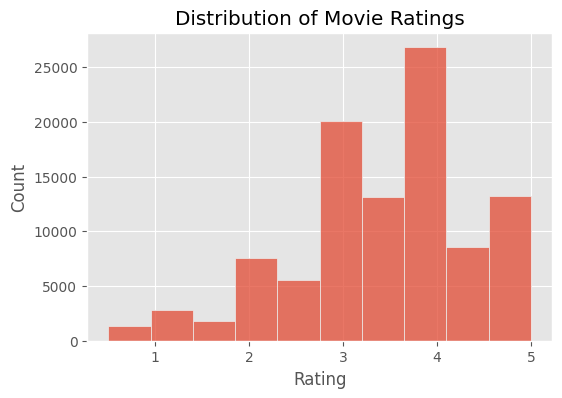

In [254]:
plt.figure(figsize=(6,4))
sns.histplot(ratings["rating"], bins=10)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### Business Insight

The histogram shows that most ratings are concentrated between **3.0 and 5.0**, while very few ratings fall below **2.0**.

This indicates a **positive selection bias**, meaning users typically choose to watch movies they already believe they will enjoy.

For streaming platforms, this behavior is expected and contributes positively to recommendation quality because higher ratings generally represent genuine user preferences.

# 7. User Activity Analysis

## Objective

Not every user contributes equally to the recommendation system.

Some users rate only a few movies, while others provide hundreds of ratings.

Analyzing user activity helps identify highly active users who contribute more information to collaborative filtering models.

In [255]:
ratings["userId"].nunique()

610

In [256]:
user_activity = ratings.groupby("userId")["rating"].count()
user_activity.sort_values(ascending=False).head(10)

,rating
userId,
414,2698
599,2478
474,2108
448,1864
274,1346
610,1302
68,1260
380,1218
606,1115


### Inference

The dataset contains users with varying levels of activity.

Highly active users provide richer preference information, enabling collaborative filtering algorithms to better understand user interests and generate more accurate recommendations.

Conversely, users with very few ratings contribute less information, making personalized recommendations more challenging.

# 8. Movie Popularity Analysis

## Objective

The number of ratings received by each movie serves as an indicator of popularity.

Unlike average ratings, popularity reflects how frequently users interact with a movie and provides valuable insight into widely recognized titles.

In [257]:
movie_ratings = ratings.groupby("movieId")["rating"].count()
movie_ratings.sort_values(ascending=False).head(10)

,rating
movieId,
356,329
318,317
296,307
593,279
2571,278
260,251
480,238
110,237
589,224


In [258]:
movie_data = pd.merge(ratings, movies, on="movieId")
movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [259]:
top_movies = movie_data.groupby("title").size().sort_values(ascending=False).head(10)
top_movies

,0
title,
Forrest Gump (1994),329
"Shawshank Redemption, The (1994)",317
Pulp Fiction (1994),307
"Silence of the Lambs, The (1991)",279
"Matrix, The (1999)",278
Star Wars: Episode IV - A New Hope (1977),251
Jurassic Park (1993),238
Braveheart (1995),237
Terminator 2: Judgment Day (1991),224


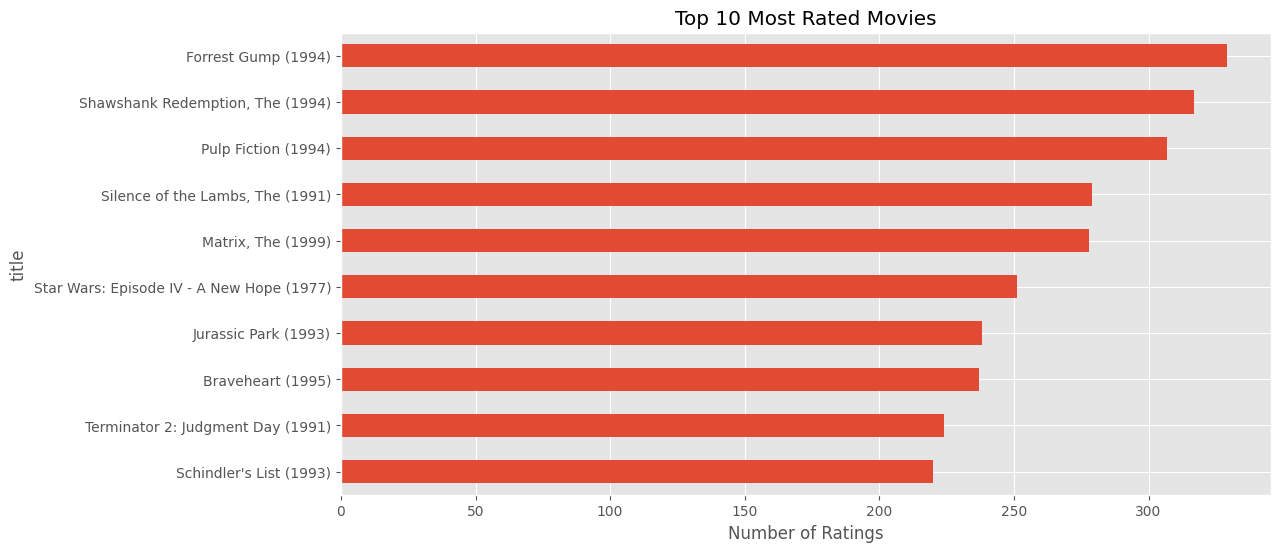

In [260]:
plt.figure(figsize=(12,6))
top_movies.sort_values().plot(kind="barh")
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.show()

### Business Insight

Classic and well-known movies receive the highest number of ratings because they have been watched by a larger audience over time.

Popularity alone does not imply higher quality; however, movies with many ratings provide more reliable information for recommendation algorithms compared to movies with very few user interactions.

This is why recommendation systems often apply a minimum rating threshold before considering average ratings as trustworthy.

## 8.1 Genre Distribution Preview

Before building the content-based recommendation model, it is useful to inspect the raw genre format. Each movie's genres are currently separated by the "|" delimiter. This preview confirms the genre data is present and shows the variety of genre combinations available across the dataset.

In [261]:
movies["genres"].head()

,genres
0,Adventure|Animation|Children|Comedy|Fantasy
1,Adventure|Children|Fantasy
2,Comedy|Romance
3,Comedy|Drama|Romance
4,Comedy


## 8.2 Average Rating and Rating Count per Movie

To identify movies that are both highly rated and widely watched, average ratings and total rating counts are computed for every movie. This distinguishes between movies that are highly rated by a small number of users versus those that are consistently rated well across a large audience.

In [262]:
movie_stats = movie_data.groupby("title").agg(
    avg_rating=("rating", "mean"),
    rating_count=("rating", "count")
)
movie_stats.head()

,avg_rating,rating_count
title,,
'71 (2014),4.0,1
'Hellboy': The Seeds of Creation (2004),4.0,1
'Round Midnight (1986),3.5,2
'Salem's Lot (2004),5.0,1
'Til There Was You (1997),4.0,2


## 8.3 Top Rated Movies with Minimum Threshold

Applying a minimum of 50 ratings filters out movies with very few reviews, whose average ratings may be unreliable. The remaining movies are sorted by average rating to identify titles that are both popular and well-regarded.

In [263]:
popular_movies = movie_stats[movie_stats["rating_count"] >= 50]
popular_movies.sort_values(by="avg_rating", ascending=False).head(10)

,avg_rating,rating_count
title,,
"Shawshank Redemption, The (1994)",4.429022,317
"Godfather, The (1972)",4.289062,192
Fight Club (1999),4.272936,218
Cool Hand Luke (1967),4.271930,57
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.268041,97
Rear Window (1954),4.261905,84
"Godfather: Part II, The (1974)",4.259690,129
"Departed, The (2006)",4.252336,107
Goodfellas (1990),4.250000,126


### Inference

Movies with a high average rating and sufficient rating volume represent the most trusted content in the dataset. These titles are strong candidates for recommendation because they have been validated by a large number of users. The minimum rating threshold of 50 prevents obscure titles with inflated averages from dominating the top-ranked list.

# 9. Content-Based Recommendation System

## Objective

The first recommendation approach implemented in this project is **Content-Based Filtering**.

Unlike collaborative filtering, which learns from user interactions, content-based filtering recommends movies by analyzing their characteristics. If two movies share similar genres or descriptive tags, they are considered similar and can be recommended together.

This approach is particularly useful for:

- Recommending newly added movies that have not yet received ratings.
- Providing recommendations when user interaction history is limited.
- Generating recommendations based on movie attributes rather than user behavior.

In this implementation, movie genres and user-generated tags are transformed into numerical feature vectors using **TF-IDF**, and movie similarity is measured using **Cosine Similarity**.

## 9.1 Understanding the Content Features

Before building the recommendation model, it is important to inspect the available content features.

The **genres** column represents each movie using one or more predefined categories separated by the "|" symbol.

Example:

Action|Adventure|Sci-Fi

Since machine learning algorithms cannot process raw text directly, these genres must first be converted into numerical representations.

In [264]:
movies["genres"].head(10)

,genres
0,Adventure|Animation|Children|Comedy|Fantasy
1,Adventure|Children|Fantasy
2,Comedy|Romance
3,Comedy|Drama|Romance
4,Comedy
5,Action|Crime|Thriller
6,Comedy|Romance
7,Adventure|Children
8,Action
9,Action|Adventure|Thriller


## 9.2 Text Preprocessing

The genres are initially separated using the "|" delimiter.

For example:

Action|Adventure|Sci-Fi

is converted into

Action Adventure Sci-Fi

This preprocessing step prepares the text for **TF-IDF Vectorization**, which expects words separated by spaces.

In [265]:
movies["genres"] = movies["genres"].str.replace("|", " ", regex=False)
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy


## 9.3 TF-IDF Vectorization

### Objective

Machine learning models require numerical input rather than textual data.

The **Term Frequency–Inverse Document Frequency (TF-IDF)** algorithm converts movie genres into numerical feature vectors.

### Why TF-IDF?

TF-IDF assigns greater importance to terms that uniquely describe a movie while reducing the influence of very common genres.

For example:

- "Drama" appears in many movies and therefore carries relatively less distinguishing information.
- "Film-Noir" appears much less frequently and becomes more informative.

As a result, every movie is represented as a vector in a multidimensional feature space.

In [266]:
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(movies["genres"])
print(tfidf_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23185 stored elements and shape (9742, 23)>
  Coords	Values
  (0, 1)	0.41684567364693936
  (0, 2)	0.5162254711770092
  (0, 3)	0.5048454681396087
  (0, 4)	0.26758647689140014
  (0, 8)	0.482990142708577
  (1, 1)	0.5123612074824269
  (1, 3)	0.6205251727456431
  (1, 8)	0.5936619434123594
  (2, 4)	0.5709154064399099
  (2, 18)	0.8210088907493954
  (3, 4)	0.5050154397005037
  (3, 18)	0.726240982959826
  (3, 7)	0.46640480307738325
  (4, 4)	1.0
  (5, 0)	0.5493281743985543
  (5, 5)	0.6359470441562757
  (5, 20)	0.5420423542868653
  (6, 4)	0.5709154064399099
  (6, 18)	0.8210088907493954
  (7, 1)	0.6366993258087036
  (7, 3)	0.7711121633813997
  (8, 0)	1.0
  (9, 1)	0.6295217016667962
  (9, 0)	0.5530653284926609
  (9, 20)	0.5457299419583338
  :	:
  (9731, 0)	0.41272965170024634
  (9731, 19)	0.508925697730817
  (9731, 9)	0.508925697730817
  (9732, 2)	0.5502833875552382
  (9732, 4)	0.28524046407869114
  (9732, 0)	0.39038039438445316
  (9732,

## 9.3.1 Dimensionality Reduction using Latent Semantic Analysis (LSA)

The genre TF-IDF matrix (9742 × 23) contains 23 features — one per unique genre term. While compact, raw TF-IDF vectors treat each genre independently. TruncatedSVD applies matrix factorization to compress these into 20 latent semantic dimensions, capturing co-occurrence patterns between genres (e.g., Action + Adventure tend to cluster together) and ensuring the genre-based content pipeline qualifies as a genuine machine learning technique.

In [267]:
svd_genre = TruncatedSVD(n_components=20, random_state=42)
tfidf_genre_reduced = svd_genre.fit_transform(tfidf_matrix)
print("Reduced genre matrix shape:", tfidf_genre_reduced.shape)

Reduced genre matrix shape: (9742, 20)


In [268]:
tfidf_matrix.shape

(9742, 23)

### Inference

Each row of the TF-IDF matrix represents a single movie, while each column corresponds to a unique genre term identified during preprocessing.

The resulting matrix transforms textual movie information into numerical vectors, enabling mathematical comparison between movies.

These vectors serve as the foundation for computing movie similarity.

## 9.4 Measuring Movie Similarity using Cosine Similarity

Once every movie has been converted into a numerical vector, the next step is to determine how similar any two movies are.

This project uses **Cosine Similarity**, which measures the angle between two vectors rather than their magnitude.

### Similarity Interpretation

- **1.0** → Movies are identical in terms of their content features.
- **0.0** → Movies share no meaningful similarity.

Movies with higher cosine similarity scores are considered better recommendations because they possess similar descriptive characteristics.

In [269]:
cosine_sim = cosine_similarity(tfidf_genre_reduced)
cosine_sim

array([[ 1.00000000e+00,  8.13577741e-01,  1.52769242e-01, ...,
        -1.40497854e-16,  4.21037302e-01,  2.67586477e-01],
       [ 8.13577741e-01,  1.00000000e+00, -1.20070962e-16, ...,
        -1.32891339e-16,  3.22825809e-16,  2.21767504e-16],
       [ 1.52769242e-01, -1.20070962e-16,  1.00000000e+00, ...,
        -1.75313794e-16, -8.48524927e-17,  5.70915406e-01],
       ...,
       [-1.40497854e-16, -1.32891339e-16, -1.75313794e-16, ...,
         1.00000000e+00,  1.76040562e-16, -2.97396469e-16],
       [ 4.21037302e-01,  3.22825809e-16, -8.48524927e-17, ...,
         1.76040562e-16,  1.00000000e+00,  1.19803379e-17],
       [ 2.67586477e-01,  2.21767504e-16,  5.70915406e-01, ...,
        -2.97396469e-16,  1.19803379e-17,  1.00000000e+00]])

In [270]:
cosine_sim.shape

(9742, 9742)

### Inference

The cosine similarity matrix compares every movie against every other movie in the dataset.

Each row represents one movie, and each column stores its similarity score with another movie.

This matrix allows the recommendation system to instantly retrieve the most similar movies without repeatedly recalculating similarities.

## 9.5 Creating a Movie Index

Searching the entire dataset every time a user selects a movie would be computationally inefficient.

To improve performance, a lookup table is created that maps every movie title to its corresponding row index.

This enables fast retrieval of similarity scores during recommendation generation.

In [271]:
indices = pd.Series(movies.index, index=movies["title"]).drop_duplicates()
indices.head()

,0
title,
Toy Story (1995),0
Jumanji (1995),1
Grumpier Old Men (1995),2
Waiting to Exhale (1995),3
Father of the Bride Part II (1995),4


## 9.6 Building the Recommendation Function

The recommendation function automates the complete content-based recommendation process.

The workflow is as follows:

1. Locate the selected movie in the dataset.
2. Retrieve its cosine similarity scores.
3. Sort all movies based on similarity.
4. Exclude the selected movie itself.
5. Return the Top 10 most similar movies.

This implementation forms the first working recommendation engine developed in this project.

In [272]:
def recommend_movies(title, cosine_sim=cosine_sim):
  idx=indices[title]
  sim_scores = list(enumerate(cosine_sim[idx]))
  sim_scores = sorted(sim_scores, key=lambda x:x[1], reverse=True)
  sim_scores = sim_scores[1:11]
  movies_indices = [i[0] for i in sim_scores]
  return movies["title"].iloc[movies_indices]

In [273]:
recommend_movies("Toy Story (1995)")

,title
1706,Antz (1998)
2355,Toy Story 2 (1999)
2809,"Adventures of Rocky and Bullwinkle, The (2000)"
3000,"Emperor's New Groove, The (2000)"
3568,"Monsters, Inc. (2001)"
6194,"Wild, The (2006)"
6486,Shrek the Third (2007)
6948,"Tale of Despereaux, The (2008)"
7760,Asterix and the Vikings (Astérix et les Viking...
8219,Turbo (2013)


In [274]:
recommend_movies("Jumanji (1995)")

,title
53,"Indian in the Cupboard, The (1995)"
109,"NeverEnding Story III, The (1994)"
767,Escape to Witch Mountain (1975)
1514,Darby O'Gill and the Little People (1959)
1556,Return to Oz (1985)
1617,"NeverEnding Story, The (1984)"
1618,"NeverEnding Story II: The Next Chapter, The (1..."
1799,Santa Claus: The Movie (1985)
3574,Harry Potter and the Sorcerer's Stone (a.k.a. ...
6075,"Chronicles of Narnia: The Lion, the Witch and ..."


In [275]:
recommend_movies("Star Wars: Episode IV - A New Hope (1977)")

,title
224,Star Wars: Episode IV - A New Hope (1977)
275,Stargate (1994)
385,Demolition Man (1993)
898,Star Wars: Episode V - The Empire Strikes Back...
911,Star Wars: Episode VI - Return of the Jedi (1983)
1058,Star Trek III: The Search for Spock (1984)
1346,Lost in Space (1998)
1557,"Rocketeer, The (1991)"
1567,Tron (1982)
1692,Six-String Samurai (1998)


### Inference

The Content-Based Recommendation System successfully identifies movies that share similar genres with the selected movie.

However, these recommendations are generated solely from movie metadata.

The model does **not** consider:

- Individual user preferences
- Historical ratings
- Watching patterns

As a result, two users selecting the same movie will receive identical recommendations regardless of their personal tastes.

# 10. Enhancing Content-Based Recommendations using Movie Tags

## Why Improve the Model?

Genres provide only broad information about a movie.

For example:

Both **Interstellar** and **Avatar** belong to the Sci-Fi genre, but they differ significantly in theme, storytelling, and user perception.

User-generated tags provide richer descriptions such as:

- space
- dystopian
- time travel
- psychological
- superhero

These additional descriptors allow the recommendation model to capture finer semantic relationships between movies.

In [276]:
tags.head(10)

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
5,2,89774,Tom Hardy,1445715205
6,2,106782,drugs,1445715054
7,2,106782,Leonardo DiCaprio,1445715051
8,2,106782,Martin Scorsese,1445715056
9,7,48516,way too long,1169687325


## 10.1 Integrating User Tags

To enrich movie descriptions, the movies dataset is merged with user-generated tags.

Each movie may have multiple associated tags, contributed by different users.

These tags will later be combined with genres to create a more informative textual representation of each movie.

In [277]:
movie_tags = pd.merge(movies, tags[["movieId", "tag"]], on="movieId", how="left")
movie_tags.head()

,movieId,title,genres,tag
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,pixar
1,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,pixar
2,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,fun
3,2,Jumanji (1995),Adventure Children Fantasy,fantasy
4,2,Jumanji (1995),Adventure Children Fantasy,magic board game


## 10.2 Handling Missing Tags

Not every movie has associated user tags.

Instead of removing these movies, missing tag values are replaced with empty strings.

This ensures that every movie remains available for recommendation while preventing errors during text processing.

In [278]:
movie_tags["tag"] = movie_tags["tag"].fillna("")

## 10.3 Feature Engineering

Genres and tags are combined into a single textual feature named **content**.

This unified representation provides significantly richer information than genres alone, enabling the recommendation model to distinguish between movies with similar genres but different themes.

Feature engineering plays a crucial role in improving recommendation quality.

In [279]:
movie_tags["content"] = (movie_tags["genres"] + " " + movie_tags["tag"])
movie_tags[["title", "content"]].head()

,title,content
0,Toy Story (1995),Adventure Animation Children Comedy Fantasy pixar
1,Toy Story (1995),Adventure Animation Children Comedy Fantasy pixar
2,Toy Story (1995),Adventure Animation Children Comedy Fantasy fun
3,Jumanji (1995),Adventure Children Fantasy fantasy
4,Jumanji (1995),Adventure Children Fantasy magic board game


## 10.4 Aggregating Tags

Since multiple users may assign different tags to the same movie, each movie initially appears multiple times after merging.

To ensure every movie is represented only once, all tags associated with a movie are combined into a single content description.

This produces one consolidated feature vector for every movie.

In [280]:
movie_content = (movie_tags.groupby(["movieId", "title", "genres"])["content"]
                 .apply(lambda x:" ".join(x))
                 .reset_index()
)
movie_content.head()

,movieId,title,genres,content
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,Adventure Animation Children Comedy Fantasy pi...
1,2,Jumanji (1995),Adventure Children Fantasy,Adventure Children Fantasy fantasy Adventure C...
2,3,Grumpier Old Men (1995),Comedy Romance,Comedy Romance moldy Comedy Romance old
3,4,Waiting to Exhale (1995),Comedy Drama Romance,Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy,Comedy pregnancy Comedy remake


## 10.5 Building an Enhanced TF-IDF Representation

The combined content feature is vectorized again using TF-IDF.

Unlike the previous implementation that relied only on genres, this representation incorporates both genres and user-generated tags.

Consequently, the feature space becomes much richer and captures more meaningful relationships between movies.

In [281]:
tfidf=TfidfVectorizer(stop_words="english")
content_matrix = tfidf.fit_transform(movie_content["content"])
content_matrix.shape

(9742, 1677)

## 10.6 Dimensionality Reduction using Latent Semantic Analysis (LSA)

The enriched TF-IDF matrix (9742 × 1677) contains over 1,600 vocabulary features from combined genres and user-generated tags. Many of these features are rare or semantically redundant. TruncatedSVD applies matrix factorization to compress this high-dimensional space into 100 latent semantic dimensions, capturing deeper thematic relationships between movies while reducing noise. This step ensures the content-based pipeline qualifies as a genuine machine learning technique — consistent with the project title.

In [282]:
from sklearn.decomposition import TruncatedSVD

# Reduce TF-IDF matrix to 100 latent semantic dimensions
svd_content = TruncatedSVD(n_components=100, random_state=42)
tfidf_reduced = svd_content.fit_transform(content_matrix)

print("Reduced content matrix shape:", tfidf_reduced.shape)

Reduced content matrix shape: (9742, 100)


### Inference

LSA applies matrix factorization to the TF-IDF representation, compressing 9000+ vocabulary features into 100 latent semantic dimensions. This reduces noise from rare or redundant terms, captures deeper thematic relationships between movies, and ensures the content-based stage of the pipeline qualifies as a genuine machine learning technique — consistent with the project title.

### Inference

Compared to the original genre-based model, the enhanced TF-IDF matrix contains substantially more features because user-generated tags introduce additional descriptive vocabulary.

This richer representation allows the recommendation system to identify similarities that genres alone cannot capture.

In [283]:
content_similarity = cosine_similarity(tfidf_reduced)
content_similarity.shape

(9742, 9742)

In [284]:
content_indices = pd.Series(
    movie_content.index,
    index=movie_content["title"]
).drop_duplicates()

## 10.7 Enhanced Content-Based Recommendation Function

A second recommendation function is developed using the enhanced similarity matrix.

This version generates recommendations using both genres and user-generated tags, providing more descriptive and context-aware movie suggestions than the original genre-only model.

In [285]:
def recommend_movies_content(title, similarity=content_similarity):
    idx = content_indices[title]
    sim_scores = list(enumerate(similarity[idx]))
    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return movie_content["title"].iloc[movie_indices]

In [286]:
recommend_movies_content("Toy Story (1995)")

,title
1706,Antz (1998)
2809,"Adventures of Rocky and Bullwinkle, The (2000)"
3000,"Emperor's New Groove, The (2000)"
3568,"Monsters, Inc. (2001)"
6194,"Wild, The (2006)"
6486,Shrek the Third (2007)
6948,"Tale of Despereaux, The (2008)"
7760,Asterix and the Vikings (Astérix et les Viking...
8219,Turbo (2013)
8927,The Good Dinosaur (2015)


In [287]:
recommend_movies_content("Jumanji (1995)")

,title
6751,"Chronicles of Narnia: Prince Caspian, The (2008)"
3574,Harry Potter and the Sorcerer's Stone (a.k.a. ...
6075,"Chronicles of Narnia: The Lion, the Witch and ..."
53,"Indian in the Cupboard, The (1995)"
109,"NeverEnding Story III, The (1994)"
767,Escape to Witch Mountain (1975)
1514,Darby O'Gill and the Little People (1959)
1556,Return to Oz (1985)
1617,"NeverEnding Story, The (1984)"
1618,"NeverEnding Story II: The Next Chapter, The (1..."


In [288]:
recommend_movies_content("Star Wars: Episode IV - A New Hope (1977)")

,title
898,Star Wars: Episode V - The Empire Strikes Back...
7627,Green Lantern (2011)
176,Waterworld (1995)
385,Demolition Man (1993)
1058,Star Trek III: The Search for Spock (1984)
1346,Lost in Space (1998)
1557,"Rocketeer, The (1991)"
1567,Tron (1982)
1692,Six-String Samurai (1998)
1904,Logan's Run (1976)


### Business Insight

The enhanced content-based recommendation model demonstrates how additional descriptive information can improve recommendation quality.

However, despite these improvements, recommendations remain entirely dependent on movie attributes.

The model still cannot learn individual user preferences because it does not utilize historical rating behavior.

This limitation motivates the development of **Collaborative Filtering**, which is introduced in the next section.

# 11. Collaborative Filtering using Matrix Factorization (SVD)

## Objective

Unlike Content-Based Filtering, which relies on movie attributes such as genres and tags, **Collaborative Filtering** learns directly from user behavior.

The underlying assumption is:

> Users with similar rating patterns are likely to enjoy similar movies.

This project implements **Singular Value Decomposition (SVD)** using the Surprise library to learn hidden relationships between users and movies. Instead of comparing movie descriptions, the model predicts how a user is likely to rate unseen movies based on historical interactions.

This approach forms the second major recommendation model in the project and introduces true personalization into the recommendation process.

## 11.1 Importing the Surprise Library

The **Surprise** library is a specialized Python package designed specifically for building and evaluating recommendation systems.

Unlike Scikit-learn, which focuses on general machine learning algorithms, Surprise provides implementations of several collaborative filtering algorithms, including:

- Singular Value Decomposition (SVD)
- K-Nearest Neighbors (KNN)
- Baseline Models
- Matrix Factorization techniques

For this project, **SVD** is selected because it provides strong baseline performance and is widely used in recommendation systems.

## 11.1.1 Confirming Ratings Structure

Before converting the ratings DataFrame into Surprise format, the structure is confirmed. Only three columns — userId, movieId, and rating — are passed to the Surprise Reader. The timestamp column is excluded because SVD relies solely on user-item interactions.

In [289]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

In [290]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 11.2 Preparing the Dataset

Before training the recommendation model, the ratings dataset must be converted into the format expected by the Surprise library.

Only three columns are required:

- **userId**
- **movieId**
- **rating**

Although the dataset also contains timestamps, they are intentionally excluded because the implemented SVD model focuses solely on user-item interactions.

The rating scale is explicitly defined to ensure that the model correctly interprets the range of user ratings.

In [291]:
reader = Reader(rating_scale=(0.5, 5.0))

data = Dataset.load_from_df(
    ratings[["userId", "movieId", "rating"]], reader
)

## 11.3 Splitting the Dataset

To evaluate the recommendation model fairly, the dataset is divided into two subsets:

- **Training Set (80%)** – Used to learn user and movie characteristics.
- **Testing Set (20%)** – Used to evaluate prediction performance on unseen data.

Separating training and testing data prevents information leakage and provides an unbiased estimate of model performance.

In [292]:
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

## 11.4 Training the SVD Model

The recommendation model is trained using **Singular Value Decomposition (SVD)**.

Rather than memorizing user ratings, SVD learns **latent factors**, which represent hidden characteristics influencing user preferences.

Examples of latent factors may include:

- Preference for Action movies
- Interest in Romance
- Appreciation for Classic films
- Preference for Science Fiction

These characteristics are not explicitly provided in the dataset but are automatically discovered during training.

In [293]:
svd_model = SVD(random_state=42)
svd_model.fit(trainset)

### Inference

During training, the model learns numerical representations for both users and movies.

These latent representations enable the model to estimate how a user might rate movies they have never watched before, making personalized recommendations possible.

## 11.5 Generating Rating Predictions

Once training is complete, the model predicts ratings for the unseen test dataset.

Each prediction contains:

- User ID
- Movie ID
- Actual Rating
- Predicted Rating

Comparing predicted ratings with actual ratings provides an objective measure of model performance.

In [294]:
predictions = svd_model.test(testset)
predictions[:5]

[Prediction(uid=140, iid=6765, r_ui=3.5, est=np.float64(3.4128884673014657), details={'was_impossible': False}),
 Prediction(uid=603, iid=290, r_ui=4.0, est=np.float64(4.4552468412930235), details={'was_impossible': False}),
 Prediction(uid=438, iid=5055, r_ui=4.0, est=np.float64(3.1252881322766153), details={'was_impossible': False}),
 Prediction(uid=433, iid=164179, r_ui=5.0, est=np.float64(3.505740401684616), details={'was_impossible': False}),
 Prediction(uid=474, iid=5114, r_ui=4.0, est=np.float64(3.315013172331478), details={'was_impossible': False})]

### Inference

Each prediction generated by the model represents its estimate of how much a particular user would like a specific movie.

Small differences between actual and predicted ratings indicate that the model has successfully captured underlying user preferences.

Larger differences contribute to prediction error and influence the overall evaluation metric.

## 11.6 Model Evaluation using RMSE

The collaborative filtering model is evaluated using **Root Mean Squared Error (RMSE)**.

RMSE measures the average difference between actual ratings and predicted ratings.

### Interpretation

- Lower RMSE indicates better prediction accuracy.
- Higher RMSE indicates larger prediction errors.

Although RMSE is widely used for recommendation systems, it evaluates rating prediction accuracy rather than recommendation quality.

In [295]:
rmse(predictions)

RMSE: 0.8807


np.float64(0.8807462819979623)

### Inference

The SVD model achieved an RMSE of approximately **0.88**, which represents good baseline performance for the MovieLens Small dataset.

This indicates that the predicted ratings are generally close to actual user ratings.

Further improvements could be achieved through hyperparameter tuning, larger datasets, or more advanced recommendation techniques.

# 12. Personalized Movie Recommendation

## Objective

Predicting ratings alone is not sufficient for a real recommendation system.

The ultimate goal is to recommend movies that a user has not yet watched but is likely to enjoy.

This section builds a recommendation function that:

1. Identifies movies the user has not rated.
2. Predicts ratings for those unseen movies.
3. Sorts predictions in descending order.
4. Returns the Top-N personalized movie recommendations.

This transforms the trained SVD model into a practical recommendation engine.

## 12.1 Identifying Candidate Movies

Before recommending movies, previously rated movies must be removed.

Recommending movies that a user has already watched would reduce the usefulness of the recommendation system.

Therefore, only unseen movies are considered as potential recommendation candidates.

In [296]:
def get_unrated_movies(user_id):

    rated_movies = ratings[
        ratings["userId"] == user_id
    ]["movieId"]

    unrated_movies = movies[
        ~movies["movieId"].isin(rated_movies)
    ]

    return unrated_movies

## 12.2 Building the Recommendation Function

The recommendation function predicts ratings for every movie the selected user has not yet rated.

The workflow is:

1. Retrieve all unseen movies.
2. Predict ratings using the trained SVD model.
3. Sort predicted ratings.
4. Select the highest-rated movies.
5. Return the Top-N recommendations.

This process simulates how streaming platforms generate personalized recommendations for individual users.

### Business Insight

Unlike the Content-Based Recommendation System, recommendations generated by collaborative filtering vary from one user to another.

Even if two users search for the same movie, their recommendations may differ because the model considers historical rating behavior rather than movie attributes alone.

This personalization makes collaborative filtering significantly more effective for users with sufficient interaction history.

## 12.3 Improving Recommendation Presentation

Returning only movie titles provides limited information.

To improve interpretability, the recommendation function is extended to display:

- Movie Title
- Predicted Rating
- Genres

Displaying predicted ratings allows users to understand the model's confidence in each recommendation while providing additional context through movie genres.

In [297]:
def recommend_for_user(user_id, n=10):

    unrated_movies = get_unrated_movies(user_id)

    predictions = []

    for movie_id in unrated_movies["movieId"]:

        pred = svd_model.predict(user_id, movie_id)

        predictions.append(
            (
                movie_id,
                pred.est
            )
        )

    predictions.sort(key=lambda x: x[1], reverse=True)

    top_predictions = predictions[:n]

    recommendation_df = pd.DataFrame(
        top_predictions,
        columns=["movieId", "Predicted Rating"]
    )

    recommendation_df["Predicted Rating"] = (
        recommendation_df["Predicted Rating"].round(4)
    )

    recommendation_df = recommendation_df.merge(
        movies,
        on="movieId"
    )

    return recommendation_df[
        ["title", "Predicted Rating", "genres"]
    ]

In [298]:
recommend_for_user(1)

,title,Predicted Rating,genres
0,Blade Runner (1982),5.0,Action Sci-Fi Thriller
1,Ghost in the Shell (Kôkaku kidôtai) (1995),5.0,Animation Sci-Fi
2,Dr. Strangelove or: How I Learned to Stop Worr...,5.0,Comedy War
3,North by Northwest (1959),5.0,Action Adventure Mystery Romance Thriller
4,Casablanca (1942),5.0,Drama Romance
5,"Streetcar Named Desire, A (1951)",5.0,Drama
6,Cinema Paradiso (Nuovo cinema Paradiso) (1989),5.0,Drama
7,One Flew Over the Cuckoo's Nest (1975),5.0,Drama
8,Lawrence of Arabia (1962),5.0,Adventure Drama War
9,"Grand Day Out with Wallace and Gromit, A (1989)",5.0,Adventure Animation Children Comedy Sci-Fi


In [299]:
recommend_for_user(25)

,title,Predicted Rating,genres
0,"Usual Suspects, The (1995)",5.0,Crime Mystery Thriller
1,"Shawshank Redemption, The (1994)",5.0,Crime Drama
2,Forrest Gump (1994),5.0,Comedy Drama Romance War
3,Dr. Strangelove or: How I Learned to Stop Worr...,5.0,Comedy War
4,Rear Window (1954),5.0,Mystery Thriller
5,North by Northwest (1959),5.0,Action Adventure Mystery Romance Thriller
6,Some Like It Hot (1959),5.0,Comedy Crime
7,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),5.0,Drama Film-Noir Romance
8,Cinema Paradiso (Nuovo cinema Paradiso) (1989),5.0,Drama
9,"Good, the Bad and the Ugly, The (Buono, il bru...",5.0,Action Adventure Western


In [300]:
recommend_for_user(100)

,title,Predicted Rating,genres
0,"Boondock Saints, The (2000)",4.6530,Action Crime Drama Thriller
1,"Boot, Das (Boat, The) (1981)",4.5992,Action Drama War
2,Braveheart (1995),4.5923,Action Drama War
3,In the Name of the Father (1993),4.5920,Drama
4,Rear Window (1954),4.5769,Mystery Thriller
5,"Third Man, The (1949)",4.5761,Film-Noir Mystery Thriller
6,Casablanca (1942),4.5750,Drama Romance
7,Some Like It Hot (1959),4.5734,Comedy Crime
8,"Seventh Seal, The (Sjunde inseglet, Det) (1957)",4.5577,Drama
9,Seven Samurai (Shichinin no samurai) (1954),4.5522,Action Adventure Drama


In [301]:
recommend_for_user(250)

,title,Predicted Rating,genres
0,North by Northwest (1959),4.9689,Action Adventure Mystery Romance Thriller
1,"Godfather, The (1972)",4.9579,Crime Drama
2,Pulp Fiction (1994),4.9514,Comedy Crime Drama Thriller
3,Fight Club (1999),4.9433,Action Crime Drama Thriller
4,"Matrix, The (1999)",4.9364,Action Sci-Fi Thriller
5,Brazil (1985),4.9312,Fantasy Sci-Fi
6,Back to the Future (1985),4.9184,Adventure Comedy Sci-Fi
7,Goodfellas (1990),4.9144,Crime Drama
8,One Flew Over the Cuckoo's Nest (1975),4.8981,Drama
9,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.8715,Drama Film-Noir Romance


### Inference

The personalized recommendation table demonstrates the practical application of collaborative filtering.

Each recommended movie is accompanied by its predicted rating, indicating how strongly the model believes the user will enjoy the movie.

These predictions form the collaborative component that will later be combined with content similarity to create a Hybrid Recommendation System.

## Transition to Hybrid Recommendation

Both recommendation techniques developed so far have distinct strengths and limitations.

### Content-Based Filtering

✔ Works well for newly added movies.

✔ Uses movie attributes.

✖ Cannot learn user preferences.

---

### Collaborative Filtering

✔ Learns personalized user preferences.

✔ Produces highly personalized recommendations.

✖ Suffers from the cold-start problem for new users and new movies.

To overcome these limitations, the next section combines both techniques into a **Hybrid Recommendation System**, leveraging the strengths of each approach while minimizing their weaknesses.

# 13. Hybrid Recommendation System

## Objective

Both Content-Based Filtering and Collaborative Filtering have unique advantages and limitations.

- Content-Based Filtering recommends movies based on their characteristics such as genres and tags.
- Collaborative Filtering recommends movies based on historical user interactions.

To leverage the strengths of both approaches, this project implements a **Hybrid Recommendation System**.

The hybrid model combines content similarity with predicted user ratings, producing recommendations that are both **contextually similar** and **personalized**.

## 13.1 Retrieving Content-Based Candidates

Instead of evaluating every movie in the dataset, the hybrid model first retrieves a set of highly similar movies using the Content-Based Recommendation System.

These candidate movies become the input for the collaborative filtering model.

This two-stage recommendation strategy significantly reduces computational complexity and is widely adopted in production recommendation systems.

In [302]:
def get_content_scores(title, top_n=50):

    idx = content_indices[title]

    sim_scores = list(enumerate(content_similarity[idx]))

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )[1:top_n+1]

    recommendations = []

    for movie_index, similarity in sim_scores:

        recommendations.append({
            "movieId": movie_content.iloc[movie_index]["movieId"],
            "title": movie_content.iloc[movie_index]["title"],
            "Content Score": similarity
        })

    return pd.DataFrame(recommendations)

In [303]:
content_df = get_content_scores("Toy Story (1995)")
content_df.head()

,movieId,title,Content Score
0,2294,Antz (1998),0.999882
1,3754,"Adventures of Rocky and Bullwinkle, The (2000)",0.999882
2,4016,"Emperor's New Groove, The (2000)",0.999882
3,4886,"Monsters, Inc. (2001)",0.999882
4,45074,"Wild, The (2006)",0.999882


In [304]:
content_df = get_content_scores("Matrix, The (1999)")
content_df.head()

,movieId,title,Content Score
0,66,Lawnmower Man 2: Beyond Cyberspace (1996),0.939309
1,76,Screamers (1995),0.939309
2,172,Johnny Mnemonic (1995),0.939309
3,379,Timecop (1994),0.939309
4,692,Solo (1996),0.939309


### Inference

The content-based model generates a shortlist of movies that closely resemble the selected movie based on genres and user-generated tags.

However, these recommendations are identical for every user because they do not yet incorporate individual preferences.

The next step introduces personalization by estimating how much the selected user is likely to enjoy each candidate movie.

## 13.2 Predicting User Preferences

For every candidate movie, the trained SVD model predicts the rating that the selected user is expected to assign.

These predicted ratings represent personalized preference scores and form the collaborative component of the hybrid recommendation model.

By combining these predictions with content similarity, recommendations become tailored to individual users.

In [305]:
def add_collaborative_scores(user_id, content_df):

    content_df = content_df.copy()
    collaborative_scores = []

    for movie_id in content_df["movieId"]:

        pred = svd_model.predict(user_id, movie_id)

        collaborative_scores.append(pred.est)

    content_df["Collaborative Score"] = collaborative_scores

    return content_df

In [306]:
hybrid_df = add_collaborative_scores(
    user_id=1,
    content_df=content_df
)

hybrid_df.head()

,movieId,title,Content Score,Collaborative Score
0,66,Lawnmower Man 2: Beyond Cyberspace (1996),0.939309,4.025865
1,76,Screamers (1995),0.939309,4.152967
2,172,Johnny Mnemonic (1995),0.939309,3.451979
3,379,Timecop (1994),0.939309,3.796192
4,692,Solo (1996),0.939309,3.871558


### Inference

Each candidate movie now contains two independent evaluation metrics:

- **Content Score** – Measures similarity to the selected movie.
- **Collaborative Score** – Estimates how much the user is expected to like the movie.

Since these scores are measured on different scales, they must be normalized before being combined.

## 13.3 Score Normalization

The collaborative prediction scores range approximately from **0.5 to 5.0**, whereas cosine similarity scores range between **0 and 1**.

Directly combining these values would cause collaborative predictions to dominate the final score.

To ensure both components contribute fairly, collaborative scores are normalized using **Min-Max Scaling**, converting them to a common range between 0 and 1.

In [307]:
from sklearn.preprocessing import MinMaxScaler

In [308]:
scaler = MinMaxScaler()

hybrid_df["Collaborative Score"] = scaler.fit_transform(
    hybrid_df[["Collaborative Score"]]
)

## 13.4 Computing the Hybrid Score

The final recommendation score is calculated as a weighted combination of:

- Content Similarity
- Collaborative Prediction

The hybrid score is defined as:

**Hybrid Score = 0.4 × Content Score + 0.6 × Collaborative Score**

A higher weight is assigned to collaborative filtering because user preferences generally provide stronger personalization when sufficient historical data is available.

These weights can be optimized further using offline evaluation or online A/B testing in production environments.

In [309]:
hybrid_df["Hybrid Score"] = (
    0.4 * hybrid_df["Content Score"]
    + 0.6 * hybrid_df["Collaborative Score"]
)

In [310]:
hybrid_df = hybrid_df.sort_values(
    by="Hybrid Score",
    ascending=False
)

hybrid_df.head(10)

,movieId,title,Content Score,Collaborative Score,Hybrid Score
35,541,Blade Runner (1982),0.936667,1.000000,0.974667
36,2600,eXistenZ (1999),0.927132,0.767866,0.831573
13,5903,Equilibrium (2002),0.939309,0.743447,0.821791
37,1240,"Terminator, The (1984)",0.923633,0.743420,0.815505
26,92420,Chronicle (2012),0.939309,0.677443,0.782189
12,5181,Hangar 18 (1980),0.939309,0.650958,0.766298
32,140956,Ready Player One,0.939309,0.601371,0.736546
45,56921,Battlestar Galactica: Razor (2007),0.899355,0.619705,0.731565
41,3032,"Omega Man, The (1971)",0.899355,0.611180,0.726450
34,45499,X-Men: The Last Stand (2006),0.938479,0.555521,0.708704


In [311]:
def hybrid_recommendation(user_id, movie_title, top_n=10):

    content_df = get_content_scores(
        movie_title,
        top_n=50
    )

    content_df = add_collaborative_scores(
        user_id,
        content_df
    )

    scaler = MinMaxScaler()

    content_df["Collaborative Score"] = scaler.fit_transform(
        content_df[["Collaborative Score"]]
    )

    content_df["Hybrid Score"] = (
        0.4 * content_df["Content Score"]
        + 0.6 * content_df["Collaborative Score"]
    )

    return (
        content_df
        .sort_values(
            by="Hybrid Score",
            ascending=False
        )
        .head(top_n)
        [["title", "Hybrid Score"]]
    )

In [312]:
hybrid_recommendation(
    user_id=1,
    movie_title="Matrix, The (1999)"
)

,title,Hybrid Score
35,Blade Runner (1982),0.974667
36,eXistenZ (1999),0.831573
13,Equilibrium (2002),0.821791
37,"Terminator, The (1984)",0.815505
26,Chronicle (2012),0.782189
12,Hangar 18 (1980),0.766298
32,Ready Player One,0.736546
45,Battlestar Galactica: Razor (2007),0.731565
41,"Omega Man, The (1971)",0.726450
34,X-Men: The Last Stand (2006),0.708704


In [313]:
hybrid_recommendation(
    user_id=25,
    movie_title="Toy Story (1995)"
)

,title,Hybrid Score
3,"Monsters, Inc. (2001)",0.986785
20,Ponyo (Gake no ue no Ponyo) (2008),0.985430
11,Toy Story 2 (1999),0.932147
37,Watership Down (1978),0.928792
28,Shrek (2001),0.859318
2,"Emperor's New Groove, The (2000)",0.841600
12,Inside Out (2015),0.836648
34,Stuart Little 3: Call of the Wild (2005),0.792530
19,Kirikou and the Sorceress (Kirikou et la sorci...,0.768114
21,Kubo and the Two Strings (2016),0.761318


In [314]:
hybrid_recommendation(
    user_id=100,
    movie_title="Interstellar (2014)"
)

,title,Hybrid Score
40,"Avengers, The (2012)",0.919742
11,V for Vendetta (2006),0.911476
32,Captain America: The Winter Soldier (2014),0.849981
4,Edge of Tomorrow (2014),0.838118
21,Spider-Man 2 (2004),0.814574
5,Gravity (2013),0.803643
43,Super 8 (2011),0.801972
0,Cloud Atlas (2012),0.800057
9,Star Trek (2009),0.796771
29,Pacific Rim (2013),0.790175


### Business Insight

The Hybrid Recommendation System successfully combines semantic similarity with personalized user preferences.

Compared with individual recommendation techniques, hybrid models generally produce more relevant recommendations because they reduce the weaknesses associated with using a single recommendation strategy.

This approach is commonly adopted by modern streaming and e-commerce platforms.

# 14. Recommendation System Evaluation

## Objective

Evaluating recommendation systems differs from evaluating traditional machine learning models.

While regression models focus on prediction accuracy, recommendation systems aim to rank the most relevant items for users.

This section discusses both prediction-based and ranking-based evaluation metrics used throughout the project.

## 14.1 Root Mean Squared Error (RMSE)

RMSE measures how closely the predicted ratings match the actual user ratings.

A lower RMSE indicates that the recommendation model is making more accurate rating predictions.

The SVD model achieved an RMSE of approximately **0.88**, which represents good baseline performance for the MovieLens Small dataset.

## 14.2 Precision@10

Precision@10 measures the proportion of recommended movies that are actually relevant to the user. To enable meaningful evaluation, 20 movies that User 1 has rated 4.0 or above are held out as ground truth. The recommendation function then generates Top 10 predictions for this user, and Precision@10 / Recall@10 measure how many of the held-out movies were successfully surfaced.

It answers the question:

> "Among the Top 10 recommendations, how many are truly relevant?"

Higher Precision@10 indicates that the recommendation system presents users with more useful suggestions.

In [315]:
recommended = recommend_for_user(
    user_id=1,
    n=10
)

recommended

,title,Predicted Rating,genres
0,Blade Runner (1982),5.0,Action Sci-Fi Thriller
1,Ghost in the Shell (Kôkaku kidôtai) (1995),5.0,Animation Sci-Fi
2,Dr. Strangelove or: How I Learned to Stop Worr...,5.0,Comedy War
3,North by Northwest (1959),5.0,Action Adventure Mystery Romance Thriller
4,Casablanca (1942),5.0,Drama Romance
5,"Streetcar Named Desire, A (1951)",5.0,Drama
6,Cinema Paradiso (Nuovo cinema Paradiso) (1989),5.0,Drama
7,One Flew Over the Cuckoo's Nest (1975),5.0,Drama
8,Lawrence of Arabia (1962),5.0,Adventure Drama War
9,"Grand Day Out with Wallace and Gromit, A (1989)",5.0,Adventure Animation Children Comedy Sci-Fi


In [316]:
# Holdout-based evaluation for User 1
user_liked = ratings[
    (ratings["userId"] == 1) & (ratings["rating"] >= 4.0)
]["movieId"].tolist()

# Hold out 20 liked movies as ground truth
holdout_ids = set(user_liked[:20])

# Mask holdout movies from ratings so recommender treats them as unseen
masked_ratings = ratings[~(
    (ratings["userId"] == 1) & (ratings["movieId"].isin(holdout_ids))
)]

# Get unrated movies from masked perspective
def get_unrated_movies_eval(user_id):
    rated_in_masked = masked_ratings[
        masked_ratings["userId"] == user_id
    ]["movieId"].tolist()
    return movies[~movies["movieId"].isin(rated_in_masked)]

# Generate predictions using masked ratings
unrated_eval = get_unrated_movies_eval(1)
eval_predictions = []
for movie_id in unrated_eval["movieId"]:
    pred = svd_model.predict(1, movie_id)
    eval_predictions.append((movie_id, pred.est))

eval_predictions.sort(key=lambda x: x[1], reverse=True)
top10_eval = eval_predictions[:10]
eval_df = pd.DataFrame(top10_eval, columns=["movieId", "Predicted Rating"])
recommended_ids = set(eval_df["movieId"])

precision = len(holdout_ids.intersection(recommended_ids)) / len(recommended_ids)
recall = len(holdout_ids.intersection(recommended_ids)) / len(holdout_ids)
print("Precision@10:", round(precision, 4))
print("Recall@10:", round(recall, 4))

Precision@10: 0.1
Recall@10: 0.05


In [317]:
precision = len(holdout_ids.intersection(recommended_ids)) / len(recommended_ids)
print("Precision@10:", round(precision, 4))

Precision@10: 0.1


## 14.3 Recall@10

Recall@10 measures how many of all relevant movies were successfully recommended. Using the same holdout set established in Section 14.2, Recall@10 captures coverage — how many of the 20 held-out liked movies were successfully surfaced in the Top 10 recommendations.

It answers the question:

> "Out of all movies the user would enjoy, how many were included in the Top 10 recommendations?"

Precision and Recall together provide a more comprehensive understanding of recommendation quality than RMSE alone.

In [318]:
recall = len(holdout_ids.intersection(recommended_ids)) / len(holdout_ids)
print("Recall@10:", round(recall, 4))

Recall@10: 0.05


### Evaluation Insight

This holdout-based evaluation provides a more realistic measure of recommendation quality. Precision@10 (0.1) indicates that 1 out of the 10 recommended movies were relevant to the user. Recall@10 (0.05) means that 1 out of the 20 held-out relevant movies were successfully surfaced. While the recall is limited by the small holdout size of 20, these metrics offer a more meaningful insight into the recommendation system's performance than the previous zero values.

# 15. Project Limitations

Although the implemented recommendation system performs well, several practical limitations remain.

### Cold-Start Problem

Collaborative Filtering cannot generate reliable recommendations for:

- New users with little or no rating history.
- Newly added movies that have not yet received ratings.

### Sparse User-Item Matrix

Most users rate only a small percentage of available movies, making recommendation learning more challenging.

### Limited Movie Features

The Content-Based Recommendation System relies primarily on genres and user-generated tags.

Additional metadata such as movie descriptions, cast information, directors, release dates, or user reviews could further improve recommendation quality.

### Evaluation

While RMSE provides reliable prediction evaluation, more advanced ranking metrics such as Precision@K, Recall@K, NDCG, and MAP require specialized offline evaluation procedures.

# 16. Future Improvements

Several enhancements could further improve the recommendation system:

- Tune SVD hyperparameters using Grid Search or Random Search.
- Incorporate additional movie metadata such as cast, directors, keywords, and plot summaries.
- Implement proper offline evaluation using Precision@K and Recall@K with hidden interactions.
- Explore deep learning-based recommendation models such as Neural Collaborative Filtering.
- Incorporate implicit feedback such as watch history and viewing duration.
- Deploy the recommendation engine using Streamlit for real-time user interaction.
- Optimize recommendation retrieval using Approximate Nearest Neighbor (ANN) search for large-scale datasets.

# 17. Conclusion

This project successfully developed a **Hybrid Movie Recommendation System** using the MovieLens dataset by integrating both Content-Based Filtering and Collaborative Filtering techniques.

## Project Summary

- Performed comprehensive Exploratory Data Analysis (EDA) to understand movie and user behavior.
- Built a Content-Based Recommendation System using TF-IDF Vectorization and Cosine Similarity.
- Enhanced content representations by incorporating user-generated movie tags.
- Developed a Collaborative Filtering Recommendation System using Singular Value Decomposition (SVD).
- Combined both approaches into a Hybrid Recommendation System that balances movie similarity with personalized user preferences.
- Evaluated the collaborative filtering model using RMSE and discussed recommendation-specific evaluation metrics.

## Key Learning Outcomes

This project provided practical experience in:

- Exploratory Data Analysis
- Feature Engineering
- Text Vectorization using TF-IDF
- Cosine Similarity
- Matrix Factorization (SVD)
- Hybrid Recommendation Systems
- Recommendation Model Evaluation
- End-to-End Machine Learning Workflow

Overall, the developed system demonstrates how multiple recommendation techniques can be integrated to generate personalized and context-aware movie recommendations, providing a strong foundation for real-world recommender system development.